In [2]:
import pandas as pd
import matplotlib.pyplot as plt

yolcu = pd.read_csv("passenger_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["date"])
sefer = pd.read_csv("trips_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["Tarih"])

print(yolcu.shape, sefer.shape)
print(yolcu.dtypes)

(678010, 13) (1489, 5)
transaction_year              int64
transaction_month             int64
transaction_day               int64
line                            str
station_name                    str
age                             str
town                            str
passage_cnt                   int64
passanger_cnt                 int64
date                 datetime64[us]
weekday                         str
is_weekend                     bool
line_code                       str
dtype: object


In [3]:
yas_sirasi = ["<20", "20-30", "30-60", "60+", "Bilinmiyor"]
yolcu["age"] = pd.Categorical(yolcu["age"], categories=yas_sirasi, ordered=True)

In [4]:
hat_yolcu = yolcu.groupby("line_code")["passanger_cnt"].sum().sort_values(ascending=False)
print(hat_yolcu)

line_code
Marmaray                     211013465
M2                           144902910
T1                           107480340
M5                           105871816
M1                           104618911
M4                           102313233
M7                            75396747
T4                            57056314
M3                            49897239
M8                            24864688
M9                            24472718
T5                            20318350
M11                           10812046
M6                             5372638
F1                             3964775
TCDD SIRKECI-KAZLICESME        3897893
IETT TUNEL                     2697027
F4                             1229968
T3                              952863
TF2                             844905
IETT NOSTALJIK TRAMVAY          386438
TF1                             221489
TCDD - HALKALI-BASAKSEHIR       112429
Name: passanger_cnt, dtype: int64


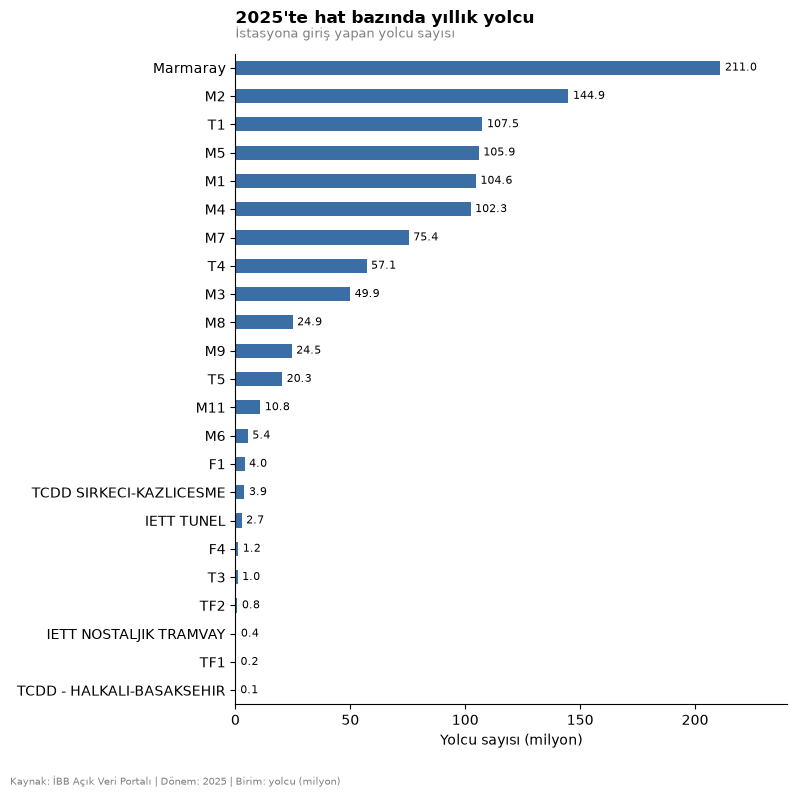

In [17]:
veri = (hat_yolcu / 1_000_000).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
veri.plot(kind="barh", ax=ax, color=ANA_RENK)

for i, deger in enumerate(veri):
    ax.text(deger + 2, i, f"{deger:.1f}", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te hat bazında yıllık yolcu", "İstasyona giriş yapan yolcu sayısı")
ax.set_xlabel("Yolcu sayısı (milyon)")
ax.set_ylabel("")
ax.set_xlim(0, 240)

footer_ekle(fig, "2025", "yolcu (milyon)")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figures/hat_bazli_yolcu.png", dpi=150)
plt.show()

In [6]:
aylik_yolcu = (
    yolcu.groupby(["line_code", "transaction_year", "transaction_month"])["passanger_cnt"]
    .sum()
    .reset_index()
    .rename(columns={"transaction_year": "year", "transaction_month": "month"})
)

print(aylik_yolcu.head())
print(aylik_yolcu.shape)

  line_code  year  month  passanger_cnt
0        F1  2025      1         333829
1        F1  2025      2         275118
2        F1  2025      3         239630
3        F1  2025      4         322788
4        F1  2025      5         357300
(276, 4)


In [7]:
sefer_2025 = sefer[sefer["year"] == 2025]
print(sefer_2025.shape)

(204, 5)


In [8]:
print(yolcu["line_code"].nunique())

23


In [9]:
birlesik = aylik_yolcu.merge(
    sefer_2025[["line_code", "year", "month", "sefer_sayisi"]],
    on=["line_code", "year", "month"],
    how="left"
)

print(birlesik[birlesik["sefer_sayisi"].isna()]["line_code"].unique())

<StringArray>
[   'IETT NOSTALJIK TRAMVAY',                'IETT TUNEL',
                       'M11',                  'Marmaray',
 'TCDD - HALKALI-BASAKSEHIR',   'TCDD SIRKECI-KAZLICESME']
Length: 6, dtype: str


In [10]:
birlesik = birlesik.dropna(subset=["sefer_sayisi"])

hat_oran = birlesik.groupby("line_code")[["passanger_cnt", "sefer_sayisi"]].sum()
hat_oran["sefer_basina_yolcu"] = hat_oran["passanger_cnt"] / hat_oran["sefer_sayisi"]
hat_oran = hat_oran.sort_values("sefer_basina_yolcu", ascending=False)

print(hat_oran.round(0))

           passanger_cnt  sefer_sayisi  sefer_basina_yolcu
line_code                                                 
M5             105871816      130864.0               809.0
M4             102313233      136202.0               751.0
M2             144902910      227721.0               636.0
M3              49897239       91869.0               543.0
M1             104618911      213478.0               490.0
T4              57056314      135550.0               421.0
M7              75396747      187814.0               401.0
T1             107480340      276281.0               389.0
M8              24864688       81973.0               303.0
M9              24472718       81330.0               301.0
T5              20318350       83417.0               244.0
M6               5372638       90863.0                59.0
T3                952863       25894.0                37.0
F1               3964775      117009.0                34.0
F4               1229968       98656.0                12

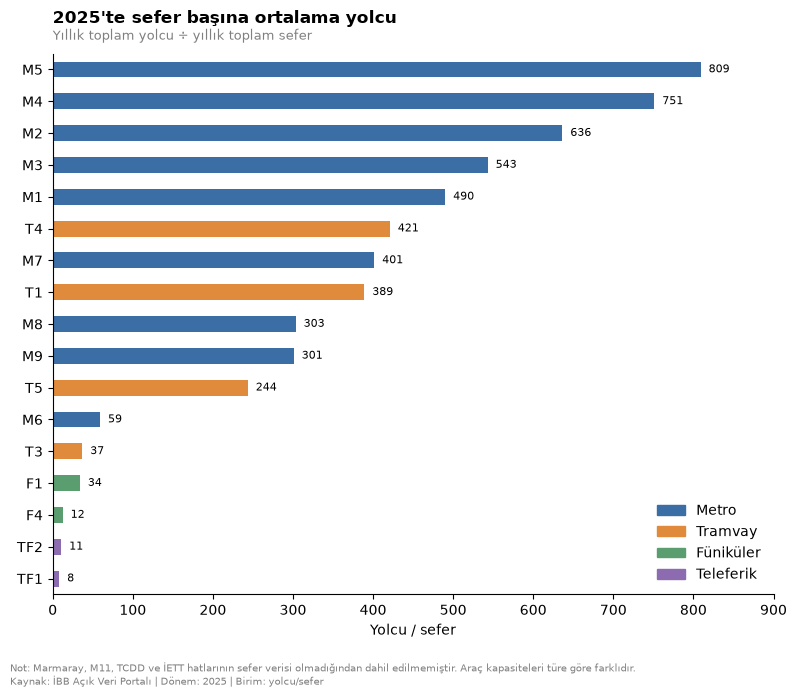

In [18]:
from matplotlib.patches import Patch

veri = hat_oran["sefer_basina_yolcu"].sort_values()

def hat_turu(kod):
    if kod.startswith("TF"):
        return "Teleferik"
    elif kod.startswith("M"):
        return "Metro"
    elif kod.startswith("T"):
        return "Tramvay"
    else:
        return "Füniküler"

tur_renk = {"Metro": "#3b6ea5", "Tramvay": "#e08a3c", "Füniküler": "#5a9e6f", "Teleferik": "#8c6bb1"}
renkler = [tur_renk[hat_turu(kod)] for kod in veri.index]

fig, ax = plt.subplots(figsize=(8, 7))
veri.plot(kind="barh", ax=ax, color=renkler)

for i, deger in enumerate(veri):
    ax.text(deger + 10, i, f"{deger:.0f}", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(color=renk, label=tur) for tur, renk in tur_renk.items()], loc="lower right", frameon=False)
baslik_ekle(ax, "2025'te sefer başına ortalama yolcu", "Yıllık toplam yolcu ÷ yıllık toplam sefer")
ax.set_xlabel("Yolcu / sefer")
ax.set_ylabel("")
ax.set_xlim(0, 900)

footer_ekle(fig, "2025", "yolcu/sefer",
            "Not: Marmaray, M11, TCDD ve İETT hatlarının sefer verisi olmadığından dahil edilmemiştir. Araç kapasiteleri türe göre farklıdır.")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("figures/sefer_basina_yolcu.png", dpi=150)
plt.show()

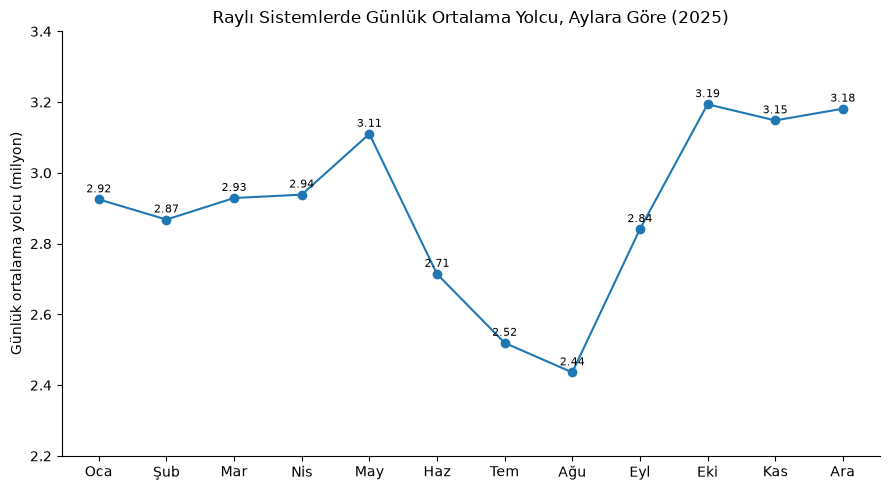

In [14]:
yolcu = pd.read_csv("passenger_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["date"])

aylik_toplam = yolcu.groupby("transaction_month")["passanger_cnt"].sum()
gun_sayisi = yolcu.groupby("transaction_month")["date"].nunique()
gunluk_ort = aylik_toplam / gun_sayisi
aylar = ["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"]
veri = gunluk_ort / 1_000_000

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(aylar, veri, marker="o")

for ay, deger in zip(aylar, veri):
    ax.text(ay, deger + 0.02, f"{deger:.2f}", ha="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Raylı Sistemlerde Günlük Ortalama Yolcu, Aylara Göre (2025)")
ax.set_ylabel("Günlük ortalama yolcu (milyon)")
ax.set_ylim(2.2, 3.4)

plt.tight_layout()
plt.savefig("figures/aylik_gunluk_ortalama.png", dpi=150)
plt.show()

In [15]:
ANA_RENK = "#3b6ea5"
KAYNAK = "İBB Açık Veri Portalı"

def baslik_ekle(ax, baslik, altbaslik=None):
    ax.set_title(baslik, loc="left", fontsize=12, fontweight="bold", pad=22 if altbaslik else 10)
    if altbaslik:
        ax.text(0, 1.02, altbaslik, transform=ax.transAxes, fontsize=9, color="gray", va="bottom")

def footer_ekle(fig, donem, birim, not_metni=None):
    satir = f"Kaynak: {KAYNAK} | Dönem: {donem} | Birim: {birim}"
    if not_metni:
        satir = not_metni + "\n" + satir
    fig.text(0.01, 0.01, satir, fontsize=7, color="gray", va="bottom")

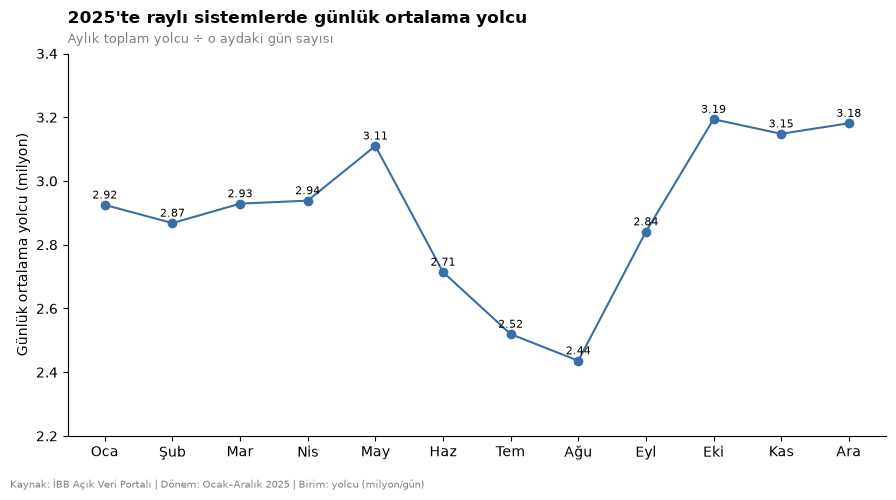

In [16]:
aylar = ["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"]
veri = gunluk_ort / 1_000_000

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(aylar, veri, marker="o", color=ANA_RENK)

for ay, deger in zip(aylar, veri):
    ax.text(ay, deger + 0.02, f"{deger:.2f}", ha="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te raylı sistemlerde günlük ortalama yolcu",
            "Aylık toplam yolcu ÷ o aydaki gün sayısı")
ax.set_ylabel("Günlük ortalama yolcu (milyon)")
ax.set_ylim(2.2, 3.4)

footer_ekle(fig, "Ocak–Aralık 2025", "yolcu (milyon/gün)")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figures/aylik_gunluk_ortalama.png", dpi=150)
plt.show()